In [ ]:
import duckdb
from pathlib import Path
import pandas as pd

current_script_parent = Path.cwd().parent
con = duckdb.connect(current_script_parent / "ipeds.duckdb")

# Filter for the year 2023 to get a row per institution
query = """
SELECT 
    h.unitid,
    h.year,
    h.institution_name,
    h.city,
    h.state,
    h.carnegie,  
    i.* EXCLUDE (unitid, year)
FROM hd h
LEFT JOIN ic i 
    ON h.unitid = i.unitid 
   AND h.year = i.year
WHERE h.year = 2023;
"""

df = con.execute(query).fetchdf()

# Force show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


In [62]:
# see NaN percentage in each column
nan_counts = df.isna().sum()
nan_percentage = (nan_counts / len(df)) * 100
display(nan_percentage)

df.describe()

unitid                0.000000
year                  0.000000
institution_name      0.000000
city                  0.000000
state                 0.000000
carnegie              0.000000
peo1istr              1.849748
peo2istr              1.849748
peo3istr              1.849748
peo4istr              1.849748
peo5istr              1.849748
peo6istr              1.849748
peo7istr              1.849748
cntlaffi              1.849748
pubprime              1.849748
pubsecon              1.849748
relaffil              1.849748
level1                1.849748
level1a               1.849748
level1b               1.849748
level2                1.849748
level3                1.849748
level4                1.849748
level5                1.849748
level6                1.849748
level7                1.849748
level8                1.849748
level12               1.849748
level17               1.849748
level18               1.849748
level19               1.849748
calsys                1.849748
ft_ug   

,unitid,year,carnegie,peo1istr,peo2istr,peo3istr,peo4istr,peo5istr,peo6istr,peo7istr,cntlaffi,pubprime,pubsecon,relaffil,level1,level1a,level1b,level2,level3,level4,level5,level6,level7,level8,level12,level17,level18,level19,calsys,ft_ug,ft_ftug,ftgdnidp,pt_ug,pt_ftug,ptgdnidp,docpp,docppsp,openadmp,noncrdt1,noncrdt2,noncrdt3,noncrdt4,noncrdt5,noncrdt6,noncrdt7,noncrdt8,noncrdt9,vet1,vet2,vet3,vet4,vet5,vet9,credits2,credits3,credits4,slo5,slo51,slo52,slo521,slo53,slo6,slo7,sloa,slo8,slo81,slo82,slo83,slob,slo9,yrscoll,stusrv2,stusrv3,stusrv4,stusrv8,stusrv9,libres1,libres2,libres3,libres4,libres5,libres6,libres9,dstnugc,dstnugp,dstnugn,dstngc,dstngp,dstngn,distcrs,distpgs,dstnced1,dstnced2,dstnced3,distnced,disab,athassoc,assoc1,assoc2,assoc3,assoc4,assoc5,assoc6,sport1,confno1,sport2,confno2,sport3,confno3,sport4,confno4,enrhsst,enrhsst1,enrhsst2,tuitpl,tuitpl1,tuitpl2,tuitpl3,tuitpl4,prmpgm,alloncam,tuitvary,room,board,applfeeu,credits1,stusrv1,libfac,admcon1,admcon2,admcon3,admcon4,admcon5,admcon6,admcon7,admcon8,admcon9,appdate,satactdt,slo3,ft_gd,pt_gd,pctpost,level9,level10,level11,ft_fp,pt_fp,apfee,accrd1,accrd2,regaccrd,accrd3,accrd4,saccr,slo1,slo2,slo4,insttoyr,fopna,fopna1,fopna2,ftstu,ptstu,rotc,rotc1,rotc2,rotc3
count,6163.000000,6163.0,6163.000000,6049.0,6049.0,6049.0,6049.0,6049.0,6049.0,6049.000000,6049.0,6049.0,6049.0,6049.0,6049.0,6049.000000,6049.000000,6049.0,6049.0,6049.0,6049.0,6049.0,6049.0,6049.0,6049.0,6049.000000,6049.000000,6049.000000,6049.0,6049.0,6049.0,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.0,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.0,6049.0,6049.0,6049.0,6049.0,6049.0,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.0,6049.0,6049.0,6049.0,6049.0,6049.0,6049.0,6049.0,6049.0,6049.0,6049.0,6049.0,6049.0,6049.0,6049.0,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,6049.000000,5696.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,286616.707123,2023.0,16.231219,0.636469,0.706894,-0.92445,0.153414,0.162506,0.060671,0.127128,2.118201,-0.392627,-1.106795,6.483551,0.560423,0.169119,0.540916,0.612498,0.437924,0.115226,-0.650355,-0.861465,-0.724417,-0.929575,0.0,-0.919656,-0.919326,-1.043313,3.209787,1.01835,1.040172,0.066127,1.250289,1.336419,0.084311,-1.574640,-1.503389,1.091255,0.236899,0.185981,0.145313,0.181187,0.107952,0.087452,0.153579,0.235576,0.514961,0.418416,0.450653,0.521408,0.237725,0.370474,0.204662,0.333278,0.507191,0.393784,0.141180,0.126633,0.002480,-0.014878,0.073566,0.285171,0.469168,0.087452,-0.409985,-0.474789,-0.640932,-0.447347,-0.002314,0.300050,-1.515953,0.873533,0.646718,0.748058,0.109109,0.007605,0.686560,0.787403,0.853860,0.619111,0.640602,0.557282,0.032071,0.467515,0.265002,0.246983,-0.987932,-1.038519,-1.270789,0.598942,0.427674,0.467019,-0.988428,0.337907,1.937180,1.106299,0.324682,-0.489172,-0.631675,-0.586874,-0.661266,-0.656472,-0.647214,0.705902,23.869896,0.614647,43.732352,0.645231,37.239709,0.621425,42.085965,1.524550,-0.759299,-0.985783,1.038023,0.056869,0.041990,0.872045,-0.006117,1.795338,1.638122,0.285998,1.606877,2.446851,32.271594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [63]:
# many institutions have no data, and many cols have no data, so drop all rows and cols with only NaNs
df_cleaned = df.dropna(how='all').dropna(axis=1, how='all')

df_cleaned = df_cleaned.dropna(thresh=len(df_cleaned.columns) * 0.1)

# drop all cols with an `x` prefix, these are imputation flags
cols_to_drop = [col for col in df_cleaned.columns if col.startswith('x')]
df_cleaned = df_cleaned.drop(columns=cols_to_drop)

# cols roomcap mealswk roomamt boardamt	rmbrdamt applfeeg indicate missing values with a '.', so replace those with NaN
cols_with_dots = ['roomcap', 'mealswk', 'roomamt', 'boardamt', 'rmbrdamt', 'applfeeg']
for col in cols_with_dots:
    df_cleaned[col] = df_cleaned[col].replace('.', pd.NA)

# let's try a few strategies for handling these
imputation_strategy = "mean" # or "0" or "delete"

if imputation_strategy == "mean":
    df_cleaned = df_cleaned.fillna(df_cleaned.mean(numeric_only=True))
elif imputation_strategy == "0":
    df_cleaned = df_cleaned.fillna(0)
elif imputation_strategy == "delete":
    df_cleaned = df_cleaned.dropna(axis=1)

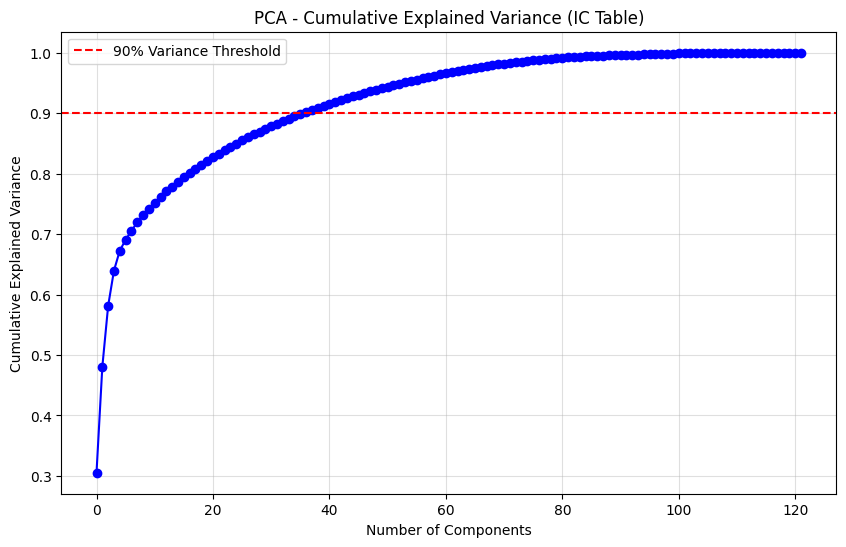

In [64]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Isolate numeric columns for PCA (exclude IDs and text metadata)
cols_to_exclude = ['unitid', 'year', 'institution_name', 'city', 'state', 'carnegie', 'sector', 'control']
numeric_cols = [col for col in df_cleaned.columns if col not in cols_to_exclude and pd.api.types.is_numeric_dtype(df_cleaned[col])]

X = df_cleaned[numeric_cols].copy()

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the PCA
pca = PCA()
df_pca = pca.fit_transform(X_scaled)

# lot the Cumulative Explained Variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='-', color='b')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance (IC Table)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

In [65]:
import plotly.express as px

# Plot 2D PCA with highlighted institutions

# Define the institutions to highlight by unitid 
highlight_unitids = [196866, # Union
                     165015, # Brandeis
                     196079, # Binghamton
                     194824, # RPI
                     195474, # Siena
                     195164, # Saint Bonaventure
                     191719, # HVCC
                     190150] # Columbia University


pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df_cleaned['PC1'] = X_pca_2d[:, 0]
df_cleaned['PC2'] = X_pca_2d[:, 1]

df_cleaned['Peer_Group'] = 'All Other Institutions'
df_cleaned['Marker_Size'] = 5 

highlight_mask = df_cleaned['unitid'].isin(highlight_unitids)
df_cleaned.loc[highlight_mask, 'Peer_Group'] = df_cleaned['institution_name']
df_cleaned.loc[highlight_mask, 'Marker_Size'] = 15

df_cleaned = df_cleaned.sort_values('Marker_Size')

fig = px.scatter(
    df_cleaned,
    x='PC1',
    y='PC2',
    color='Peer_Group',
    size='Marker_Size', 
    size_max=15,       
    hover_name='institution_name',
    hover_data={
        'PC1': False,          
        'PC2': False,         
        'Peer_Group': False,  
        'Marker_Size': False,  
        'unitid': True,       
    },
    color_discrete_map={
        'All Other Institutions': 'lightgray'
    },
    title='2D Institutional Landscape (Hover for Details)',
    labels={
        'PC1': f'Principal Component 1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)',
        'PC2': f'Principal Component 2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)'
    }
)

fig.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')), opacity=0.8)
fig.update_layout(
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray', scaleratio=1),
    yaxis=dict(showgrid=True, gridcolor='lightgray', scaleratio=1),
)

fig.show()

--- Top 16 Peers Identified ---
 unitid                           institution_name
 104717                    Grand Canyon University
 123651 Vanguard University of Southern California
 168227          Wentworth Institute of Technology
 177418                       Fontbonne University
 189705                        Canisius University
 195474                              Siena College
 198598                         Greensboro College
 199412             Queens University of Charlotte
 213987                      Mercyhurst University
 214175                         Muhlenberg College
 217013                             Wilson College
 217402                         Providence College
 217518                  Roger Williams University
 224226                  Dallas Baptist University
 234173               Virginia Wesleyan University
 236577                 Seattle Pacific University




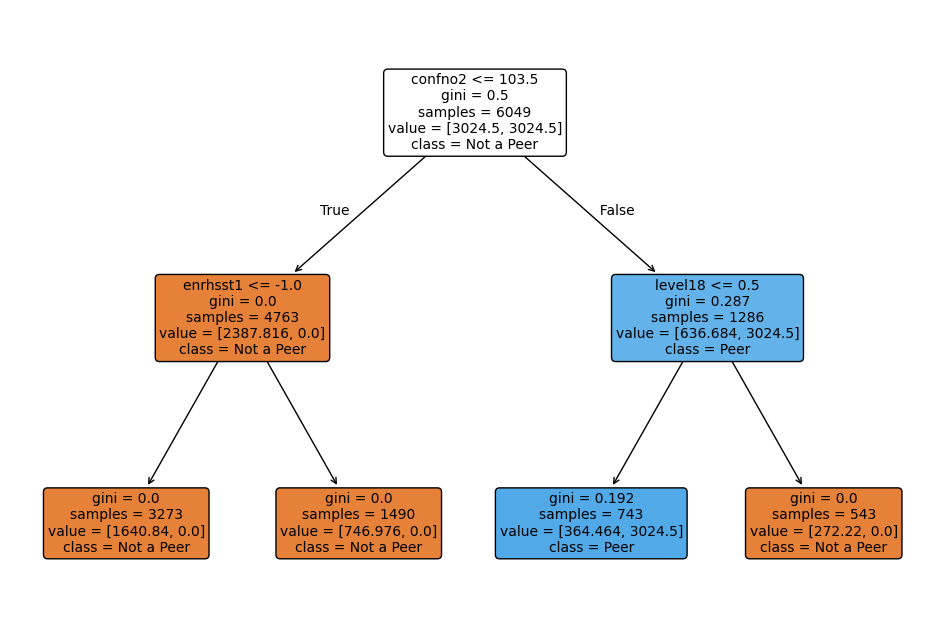

Accuracy: 0.8798148454289966
F1 Score: 0.04216073781291173


In [66]:
from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn import tree
from sklearn.metrics import accuracy_score, f1_score

# Restore df_cleaned to its original order before joining NumPy arrays!
df_cleaned = df_cleaned.sort_index()

# --- Configuration ---
target_unitids = [195474]
m_components = 38                  
n_peers = 15                      

# Run PCA with m dimensions
pca_m = PCA(n_components=m_components)
X_pca_m = pca_m.fit_transform(X_scaled)

# Find the "Centroid" of the target institutions in PCA space
# Get the row indices of our targets in the dataframe
target_indices = df_cleaned.index[df_cleaned['unitid'].isin(target_unitids)].tolist()

# Calculate the mean position of our targets across all m dimensions
centroid = X_pca_m[target_indices].mean(axis=0).reshape(1, -1)

# Find the n closest institutions to the centroid
knn = NearestNeighbors(n_neighbors=n_peers + len(target_unitids))
knn.fit(X_pca_m)
distances, indices = knn.kneighbors(centroid)

# Flatten the list of nearest neighbor indices
peer_indices = indices[0]

# Create the Machine Learning Dataset
df_ml = df_cleaned.copy()
df_ml['peer'] = 0 # Default everyone to 0

# Set the identified nearest neighbors to 1
df_ml.iloc[peer_indices, df_ml.columns.get_loc('peer')] = 1

# Let's peek at who the model selected!
selected_peers = df_ml[df_ml['peer'] == 1][['unitid', 'institution_name']]
print(f"--- Top {len(selected_peers)} Peers Identified ---")
print(selected_peers.to_string(index=False))
print("\n")

# Train the "Explainer" Decision Tree
tree_X = df_ml[numeric_cols]
tree_y = df_ml['peer']

# Max_depth=2 keeps it "heavily pruned"
clf = DecisionTreeClassifier(max_depth=2, class_weight='balanced', random_state=42)
clf.fit(tree_X, tree_y)

plt.figure(figsize=(12, 8))
tree.plot_tree(clf, 
               feature_names=numeric_cols,  
               class_names=['Not a Peer', 'Peer'], # <-- Fixed class names!
               filled=True,
               rounded=True,       # Rounds the corners of the boxes
               proportion=False,   # Change to True if you want percentages instead of decimal weights
               fontsize=10)
plt.show()

y_pred = clf.predict(tree_X)
y_true = tree_y

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy: {acc}")
print(f"F1 Score: {f1}")